In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import hypernetx as hnx

In [98]:

with open('../src/.output/graph_edges_tfl.csv', mode='r') as file:
    edges = pd.read_csv(file)

stations = pd.read_parquet('../src/.output/timetable_tfl/stations.parquet')

routes = pd.read_parquet('../src/.output/timetable_tfl/trips.parquet')
routes = [list(route) for route in routes["path"]]

In [99]:
clean_routes = []
for row in routes:
    if row not in clean_routes:
        clean_routes.append(row)
print(clean_routes[:5])


[['940GZZLUHAW', '940GZZLUKEN', '940GZZLUSKT', '940GZZLUNWY', '940GZZLUWYC', '940GZZLUSGP', '940GZZLUHSN', '940GZZLUWJN', '940GZZLUKSL', '940GZZLUQPS', '940GZZLUKPK', '940GZZLUMVL', '940GZZLUWKA', '940GZZLUPAC', '940GZZLUERB', '940GZZLUMYB', '940GZZLUBST', '940GZZLURGP', '940GZZLUOXC', '940GZZLUPCC', '940GZZLUCHX', '940GZZLUEMB', '940GZZLUWLO', '940GZZLULBN', '940GZZLUEAC'], ['940GZZLUHAW', '940GZZLUKEN', '940GZZLUSKT', '940GZZLUNWY', '940GZZLUWYC', '940GZZLUSGP', '940GZZLUHSN', '940GZZLUWJN', '940GZZLUKSL', '940GZZLUQPS', '940GZZLUKPK', '940GZZLUMVL', '940GZZLUWKA', '940GZZLUPAC', '940GZZLUERB', '940GZZLUMYB', '940GZZLUBST', '940GZZLURGP', '940GZZLUOXC', '940GZZLUPCC', '940GZZLUCHX', '940GZZLUEMB', '940GZZLUWLO'], ['940GZZLUHAW', '940GZZLUKEN', '940GZZLUSKT', '940GZZLUNWY', '940GZZLUWYC', '940GZZLUSGP', '940GZZLUHSN', '940GZZLUWJN', '940GZZLUKSL', '940GZZLUQPS'], ['940GZZLUEAC', '940GZZLULBN', '940GZZLUWLO', '940GZZLUEMB', '940GZZLUCHX', '940GZZLUPCC', '940GZZLUOXC', '940GZZLURGP', '9

In [100]:
edges.describe(include="object")

,source,target
count,357,357
unique,272,302
top,Baker Street Underground Station,Green Park Underground Station
freq,6,5


In [101]:
edges.describe()

,value
count,357.000000
mean,1.279793
std,1.009365
min,0.181281
25%,0.721138
50%,1.039438
75%,1.560350
max,11.458848


In [102]:
edges.sort_values("value")

,source,target,value
327,Reeves Corner Tram Stop,Centrale Tram Stop,0.181281
329,Centrale Tram Stop,Church Street Tram Stop,0.231236
124,Mansion House Underground Station,Cannon Street Underground Station,0.256575
33,Charing Cross Underground Station,Embankment Underground Station,0.321517
125,Cannon Street Underground Station,Monument Underground Station,0.321721
...,...,...,...
212,Wembley Park Underground Station,Harrow-on-the-Hill Underground Station,4.383127
218,Chalfont & Latimer Underground Station,Chesham Underground Station,5.410989
203,Finchley Road Underground Station,Wembley Park Underground Station,7.110420
223,Moor Park Underground Station,Harrow-on-the-Hill Underground Station,8.658662


# Degree analysis

<Figure size 800x400 with 0 Axes>

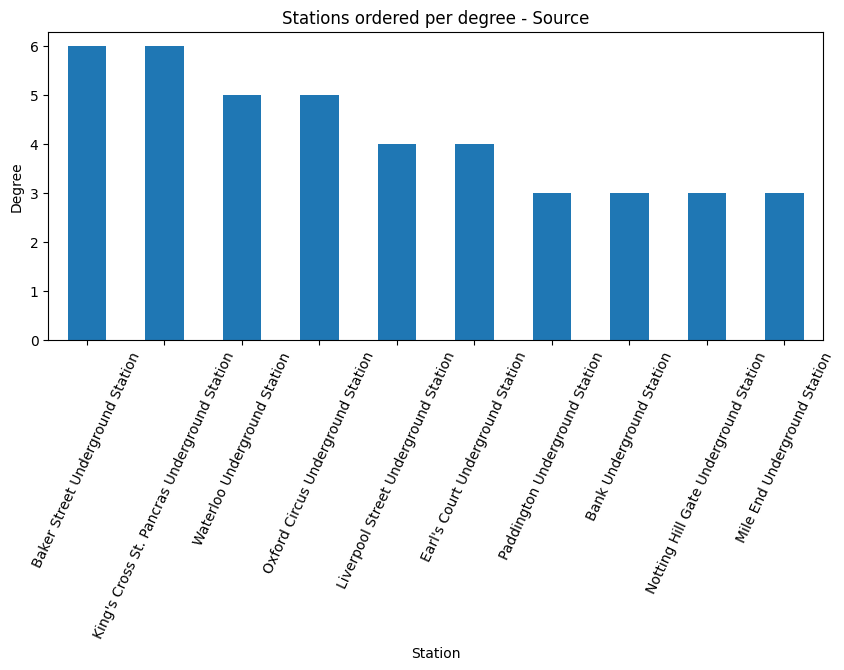

In [103]:
import matplotlib.pyplot as plt

degree = edges['source'].value_counts()

df_degree = stations.merge(degree.to_frame(), left_on="name", right_index=True)
df_degree = df_degree.sort_values("count", ascending=False)

# Top 10
top_10 = df_degree.head(10)
plt.figure(figsize=(8,4))
top_10.plot(kind='bar', x='name', y='count', legend=False,figsize=(10,4))
plt.title("Stations ordered per degree - Source")
plt.xlabel("Station")
plt.ylabel("Degree", loc='center')
plt.xticks(rotation=65, fontsize=10)
plt.show()


<Figure size 1000x400 with 0 Axes>

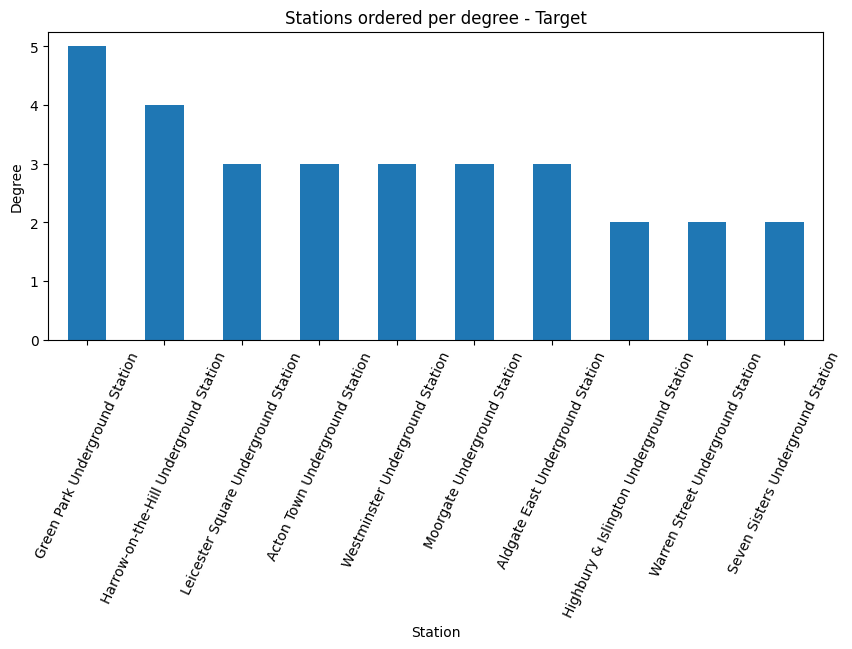

In [104]:
import matplotlib.pyplot as plt

degree = edges['target'].value_counts()

df_degree = stations.merge(degree.to_frame(), left_on="name", right_index=True)
df_degree = df_degree.sort_values("count", ascending=False)

# Top 10
top_10 = df_degree.head(10)
plt.figure(figsize=(10,4))
top_10.plot(kind='bar', x='name', y='count', legend=False,figsize=(10,4))
plt.title("Stations ordered per degree - Target")
plt.xlabel("Station")
plt.ylabel("Degree", loc='center')
plt.xticks(rotation=65, fontsize=10)
plt.show()


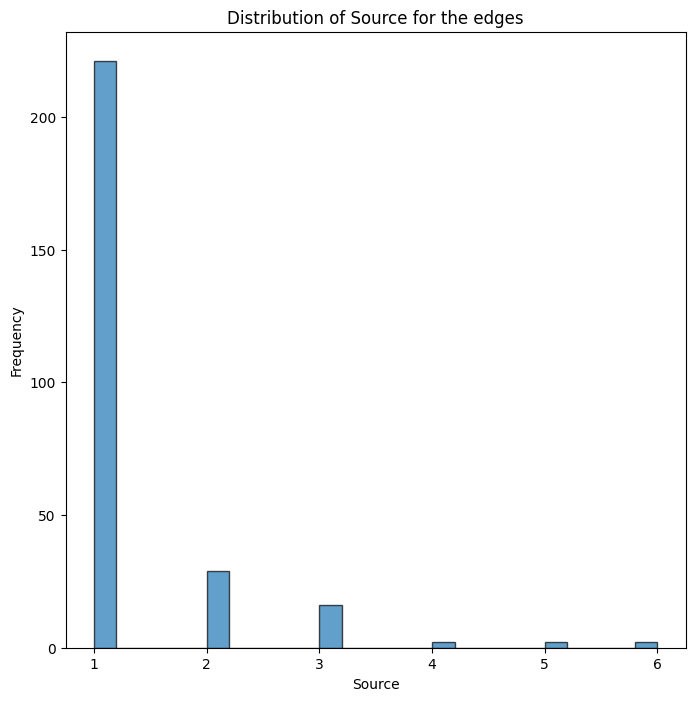

In [105]:
edges['source'].value_counts().plot(kind='hist', bins=25, edgecolor='black', alpha=0.7)
plt.title('Distribution of Source for the edges')
plt.xlabel('Source')
plt.ylabel('Frequency')
plt.show()


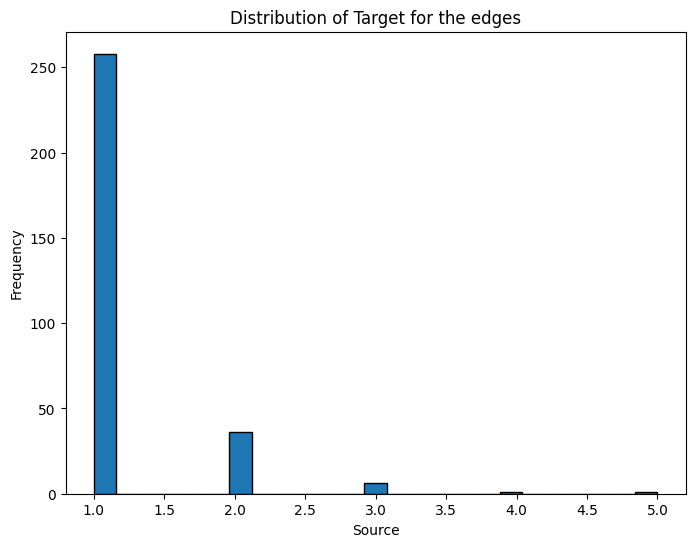

In [106]:
edges['target'].value_counts().plot(kind='hist', bins=25, edgecolor='black', alpha=1, figsize=(8,6))
plt.title('Distribution of Target for the edges')
plt.xlabel('Source')
plt.ylabel('Frequency')
plt.show()


In [107]:
edges = edges.merge(stations, left_on="source", right_on="name", how="left" )
edges = edges.merge(stations, left_on="target", right_on="name", how="left", suffixes=("_source", "_target"))

# edges = edges.drop(columns=['name_source', 'name_target'])

## Analysis of the routes

In [108]:
from collections import Counter

# Suppose routes is a list of lists like:
# [['SVG', 'WAS', 'HFN'], ['HFN', 'BAY'], ['SVG', 'BAY']]

# Flatten it
flat = [station for route in routes for station in route]

# Count frequencies
freq = Counter(flat)

# Show top 10 most common stations
print(freq.most_common(10))


[('940GZZLUKSX', 6633), ('940GZZLUCTN', 6222), ('940GZZLUEUS', 5946), ('940GZZLUKNG', 5637), ('940GZZLUSKW', 5216), ('940GZZLUBNK', 4571), ('940GZZLUMGT', 4486), ('940GZZLUEMB', 3834), ('940GZZLUOVL', 3674), ('940GZZLUCPN', 3674)]


In [109]:
freq_df = pd.DataFrame(freq.items(), columns=['station', 'count'])
freq_df = freq_df.sort_values('count', ascending=False)
freq_df.reset_index()
print(freq_df.head())


         station  count
100  940GZZLUKSX   6633
198  940GZZLUCTN   6222
199  940GZZLUEUS   5946
203  940GZZLUKNG   5637
205  940GZZLUSKW   5216


In [110]:
freq_df.describe()

,count
count,311.000000
mean,1244.807074
std,1119.354253
min,7.000000
25%,518.000000
50%,1002.000000
75%,1512.000000
max,6633.000000


In [111]:
freq_df = freq_df.merge(stations, left_on="station", right_on="id", how="left" )
freq_df.head()

,station,count,id,lat,lon,name
0,940GZZLUKSX,6633,940GZZLUKSX,51.530663,-0.123194,King's Cross St. Pancras Underground Station
1,940GZZLUCTN,6222,940GZZLUCTN,51.539292,-0.142740,Camden Town Underground Station
2,940GZZLUEUS,5946,940GZZLUEUS,51.527824,-0.131846,Euston Underground Station
3,940GZZLUKNG,5637,940GZZLUKNG,51.488337,-0.105963,Kennington Underground Station
4,940GZZLUSKW,5216,940GZZLUSKW,51.472184,-0.122644,Stockwell Underground Station


In [112]:
freq_df.describe()

,count,lat,lon
count,311.000000,311.000000,311.000000
mean,1244.807074,51.518482,-0.164251
std,1119.354253,0.070878,0.142147
min,7.000000,51.343130,-0.611247
25%,518.000000,51.492166,-0.231298
50%,1002.000000,51.520252,-0.152997
75%,1512.000000,51.562161,-0.091424
max,6633.000000,51.705208,0.250882


## Hyperdegree analysis

<Figure size 1000x500 with 0 Axes>

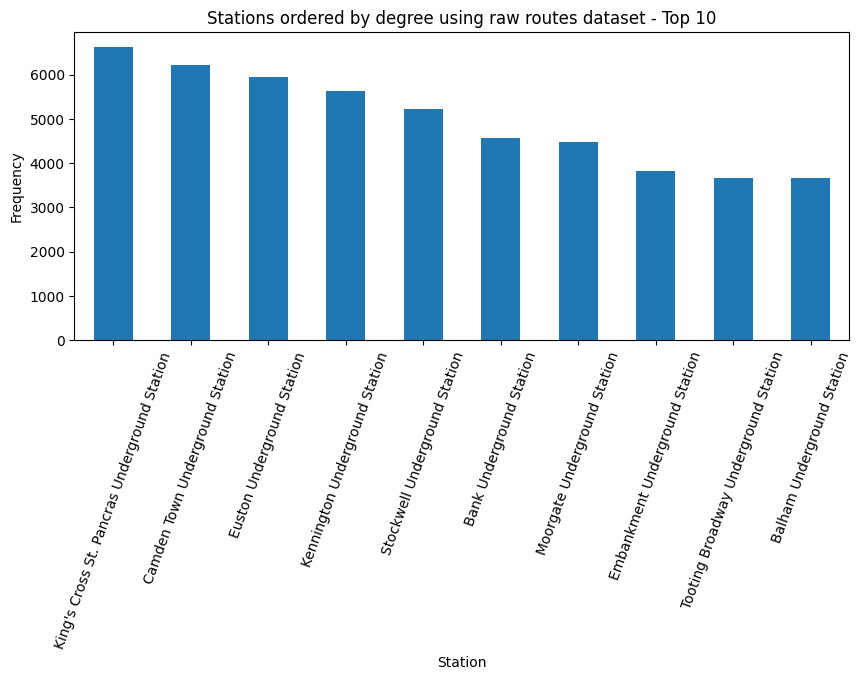

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
freq_df.head(10).plot(kind='bar', x='name', y='count', legend=False, figsize=(10,4))
plt.title("Stations ordered by degree using raw routes dataset - Top 10")
plt.xlabel("Station")
plt.ylabel("Frequency", loc='center')
plt.xticks(rotation=70)
plt.show()


In [114]:
import plotly.express as px 

fig = px.histogram(freq_df["count"], nbins=70, title="Number of routes that pass through a certain staion")

fig.show()


In [115]:
import plotly.express as px

fig = px.scatter_map(freq_df,
                    lat="lat",
                    lon="lon",
                    size="count",
                    zoom=5,
                    hover_name="name"
    )

fig.update_layout(
    
    height=600,
    map_style="carto-positron",
    geo=dict(
        center=dict(
            lat=54.5057,
            lon=-1.7274
        ),
    )
)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

## Population Analysis

In [116]:
uk_zip_code = pd.read_excel("../database/uk_la_future.xlsx",sheet_name="uk_local_authorities_future")
uk_zip_code.head()

,local-authority-code,official-name,nice-name,gss-code,start-date,end-date,replaced-by,nation,region,local-authority-type,...,lower-or-unitary,mapit-area-code,ofcom,old-ons-la-code,old-register-and-code,open-council-data-id,os-file,os,snac,wdtk-id
0,ABC,"Armagh City, Banbridge and Craigavon Borough C...","Armagh City, Banbridge and Craigavon",N09000002,2015-04-01,NaN,NaN,Northern Ireland,Northern Ireland,NID,...,True,NaN,95-OQN,NaN,local-authority-nir:ABC,1002.0,NaN,NaN,NaN,54906.0
1,ABD,Aberdeenshire Council,Aberdeenshire,S12000034,2005-06-18,NaN,NaN,Scotland,Scotland,SCO,...,True,NaN,00-QB,NaN,local-authority-sct:ABD,296.0,ABERDEENSHIRE,7.000000e+15,00QB,40.0
2,ABE,Aberdeen City Council,Aberdeen City,S12000033,2005-06-18,NaN,NaN,Scotland,Scotland,SCO,...,True,NaN,00-QA,NaN,local-authority-sct:ABE,295.0,ABERDEEN_CITY,7.000000e+15,00QA,39.0
3,ADU,Adur District Council,Adur,E07000223,NaN,NaN,NaN,England,South East,NMD,...,True,DIS,NaN,45UB,local-authority-eng:ADU,165.0,NaN,7.000000e+15,45UB,41.0
4,AGB,Argyll and Bute Council,Argyll and Bute,S12000035,2005-06-18,NaN,NaN,Scotland,Scotland,SCO,...,True,NaN,00-QD,NaN,local-authority-sct:AGB,298.0,ARGYLL_AND_BUTE,7.000000e+15,00QD,48.0


In [117]:
uk_zip_code.columns

Index(['local-authority-code', 'official-name', 'nice-name', 'gss-code',
       'start-date', 'end-date', 'replaced-by', 'nation', 'region',
       'local-authority-type', 'local-authority-type-name', 'county-la',
       'combined-authority', 'alt-names', 'former-gss-codes', 'notes',
       'current-authority', 'BS-6879', 'ecode', 'even-older-register-and-code',
       'gov-uk-slug', 'area', 'pop-2020', 'x', 'y', 'long', 'lat', 'powers',
       'lower-or-unitary', 'mapit-area-code', 'ofcom', 'old-ons-la-code',
       'old-register-and-code', 'open-council-data-id', 'os-file', 'os',
       'snac', 'wdtk-id'],
      dtype='object')

In [118]:
uk_population = pd.read_excel("../database/mye24tablesuk.xlsx",sheet_name="MYE2 - Persons", skiprows=7)
uk_population.head()

,Code,Name,Geography,All ages,0,1,2,3,4,5,...,81,82,83,84,85,86,87,88,89,90+
0,K02000001,UNITED KINGDOM,Country,69281437,667994,690113,732532,728400,755117,769993,...,414914,357410,305273,300816,281337,256103,224742,195365,167231,625236
1,K03000001,GREAT BRITAIN,Country,67353582,648105,669724,710426,706322,732313,746520,...,403452,347774,296936,293200,274184,249746,219033,190506,163096,610585
2,K04000001,ENGLAND AND WALES,Country,61806682,601329,622020,660624,656038,680640,692020,...,369527,318021,271613,268602,251783,229508,201631,175142,149932,563609
3,E92000001,ENGLAND,Country,58620101,573812,593575,630059,625948,648849,659421,...,347609,298656,255001,253116,237616,216590,190245,165268,141650,532643
4,E12000001,NORTH EAST,Region,2760678,25050,25791,27324,27213,27955,29149,...,16203,14435,12824,12644,11779,10802,9621,7940,7000,24491


In [119]:
uk_population = uk_population.loc[uk_population["Geography"]!="Country"]
uk_population.head()

,Code,Name,Geography,All ages,0,1,2,3,4,5,...,81,82,83,84,85,86,87,88,89,90+
4,E12000001,NORTH EAST,Region,2760678,25050,25791,27324,27213,27955,29149,...,16203,14435,12824,12644,11779,10802,9621,7940,7000,24491
5,E06000047,County Durham,Unitary Authority,538011,4708,4579,4876,4881,5141,5213,...,3411,2928,2706,2550,2330,2136,1971,1642,1376,4591
6,E06000005,Darlington,Unitary Authority,112489,1056,1042,1129,1134,1188,1196,...,678,605,574,568,528,460,404,340,318,1098
7,E06000001,Hartlepool,Unitary Authority,98180,947,988,1046,1045,1117,1154,...,458,477,414,434,388,389,332,239,262,849
8,E06000002,Middlesbrough,Unitary Authority,156161,1881,1900,1950,1850,1873,1946,...,685,680,568,530,503,489,399,367,324,1179


In [120]:
uk_population= uk_population.drop(uk_population.iloc[:,4:95],axis=1)
uk_population.head()

,Code,Name,Geography,All ages
4,E12000001,NORTH EAST,Region,2760678
5,E06000047,County Durham,Unitary Authority,538011
6,E06000005,Darlington,Unitary Authority,112489
7,E06000001,Hartlepool,Unitary Authority,98180
8,E06000002,Middlesbrough,Unitary Authority,156161


In [121]:
uk_population = uk_population.merge(uk_zip_code, left_on="Code", right_on="gss-code", how="left")
uk_population.head()

,Code,Name,Geography,All ages,local-authority-code,official-name,nice-name,gss-code,start-date,end-date,...,lower-or-unitary,mapit-area-code,ofcom,old-ons-la-code,old-register-and-code,open-council-data-id,os-file,os,snac,wdtk-id
0,E12000001,NORTH EAST,Region,2760678,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E06000047,County Durham,Unitary Authority,538011,DUR,Durham County Council,County Durham,E06000047,2009-04-01,NaN,...,True,UTA,00-EJ,840,local-authority-eng:DUR,338.0,COUNTY_DURHAM,7.000000e+15,00EJ,165.0
2,E06000005,Darlington,Unitary Authority,112489,DAL,Darlington Borough Council,Darlington,E06000005,1997-04-01,NaN,...,True,UTA,00-EH,841,local-authority-eng:DAL,337.0,DARLINGTON_(B),7.000000e+15,00EH,149.0
3,E06000001,Hartlepool,Unitary Authority,98180,HPL,Hartlepool Borough Council,Hartlepool,E06000001,2005-06-18,NaN,...,True,UTA,00-EB,805,local-authority-eng:HPL,369.0,HARTLEPOOL_(B),7.000000e+15,00EB,213.0
4,E06000002,Middlesbrough,Unitary Authority,156161,MDB,Middlesbrough Borough Council,Middlesbrough,E06000002,2005-06-18,NaN,...,True,UTA,00-EC,806,local-authority-eng:MDB,346.0,MIDDLESBROUGH_(B),7.000000e+15,00EC,264.0


In [122]:
uk_population.columns

Index(['Code', 'Name', 'Geography', 'All ages', 'local-authority-code',
       'official-name', 'nice-name', 'gss-code', 'start-date', 'end-date',
       'replaced-by', 'nation', 'region', 'local-authority-type',
       'local-authority-type-name', 'county-la', 'combined-authority',
       'alt-names', 'former-gss-codes', 'notes', 'current-authority',
       'BS-6879', 'ecode', 'even-older-register-and-code', 'gov-uk-slug',
       'area', 'pop-2020', 'x', 'y', 'long', 'lat', 'powers',
       'lower-or-unitary', 'mapit-area-code', 'ofcom', 'old-ons-la-code',
       'old-register-and-code', 'open-council-data-id', 'os-file', 'os',
       'snac', 'wdtk-id'],
      dtype='object')

In [123]:
uk_population = uk_population.loc[uk_population["x"]!= None]
uk_population = uk_population.loc[uk_population["y"]!= None]

In [124]:
uk_population.describe()

,All ages,area,pop-2020,x,y,long,lat,open-council-data-id,os,wdtk-id
count,3.970000e+02,379.000000,3.790000e+02,379.000000,3.790000e+02,379.000000,379.000000,373.000000,3.610000e+02,377.000000
mean,4.041811e+05,764.319261,2.469402e+05,431062.180239,3.061277e+05,52.639447,-1.573273,240.187668,7.000000e+15,2742.286472
std,1.033079e+06,1704.806532,5.006972e+05,115551.780933,1.766837e+05,1.586553,1.723603,176.335616,1.201598e+04,12719.867770
min,2.366000e+03,3.000000,2.226000e+03,43329.565502,1.302053e+04,49.936933,-7.503784,2.000000,7.000000e+15,3.000000
25%,1.142530e+05,95.000000,1.083250e+05,361484.915456,1.791781e+05,51.498099,-2.610750,123.000000,7.000000e+15,172.000000
50%,1.568750e+05,282.000000,1.482900e+05,445815.055886,2.654656e+05,52.255868,-1.327201,231.000000,7.000000e+15,278.000000
75%,2.926550e+05,715.000000,2.617385e+05,522415.726161,3.896712e+05,53.401612,-0.220773,324.000000,7.000000e+15,401.000000
max,9.642942e+06,25653.000000,9.002488e+06,647812.362211,1.168116e+06,60.394861,1.661393,1011.000000,7.000000e+15,91513.000000


In [125]:
import plotly.express as px

new_fig = px.scatter_map(uk_population,
                    lat="long",
                    lon="lat",
                    size="All ages",
                    hover_name="Name",
                    zoom=4
    )

new_fig.update_layout(
    height=600,
    map_style="carto-positron",
    geo=dict(
        center=dict(
            lat=54.5057,
            lon=-1.7274
        ),
    )
)

new_fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
new_fig.show()

# Hypergraph Analysis

In [126]:
import hypernetx.algorithms
hypergraph = hnx.Hypergraph(routes)
clean_routes_hypergraph = hnx.Hypergraph(clean_routes)
node_list = hypergraph.nodes
stations_degree = pd.DataFrame(columns=["station"])
stations_degree["station"] = node_list
stations_degree["not_clean_routes_degree"] = [hypergraph.degree(s) for s in stations_degree["station"]]
stations_degree["clean_routes_degree"] = [clean_routes_hypergraph.degree(s) for s in stations_degree["station"]]

stations_degree = stations_degree.merge(stations, left_on="station", right_on="name", how="left")


## Centrality Measures

In [127]:
## betweeness Centraily
betweeness = hypernetx.s_betweenness_centrality(clean_routes_hypergraph, edges=False)

In [128]:
print(betweeness)

{'940GZZBPSUST': 6.679221542738775e-05, '940GZZLUACT': 0.004191970735470466, '940GZZLUACY': 0.00011251767018118238, '940GZZLUADE': 0.0007267241980092581, '940GZZLUAGL': 6.679221542738775e-05, '940GZZLUALD': 0.002018395898387436, '940GZZLUALP': 0.0, '940GZZLUAMS': 0.0, '940GZZLUASG': 0.00011539883133995247, '940GZZLUASL': 0.00011539883133995247, '940GZZLUBBB': 0.0007267241980092581, '940GZZLUBBN': 0.0029775509966320384, '940GZZLUBDS': 0.00011539883133995247, '940GZZLUBEC': 6.495762628324279e-05, '940GZZLUBKE': 7.900164492710687e-06, '940GZZLUBKF': 0.0008491205191773998, '940GZZLUBKG': 0.0007267241980092581, '940GZZLUBKH': 7.900164492710687e-06, '940GZZLUBLG': 7.169076471380907e-05, '940GZZLUBLM': 0.0001274798288314974, '940GZZLUBLR': 0.0, '940GZZLUBMY': 0.0, '940GZZLUBND': 0.00942434620859812, '940GZZLUBNK': 0.018908252075161273, '940GZZLUBOR': 6.679221542738775e-05, '940GZZLUBOS': 5.642974637650491e-07, '940GZZLUBSC': 0.004674034384122908, '940GZZLUBST': 0.02978882060279731, '940GZZLUB

In [129]:
nodes = clean_routes_hypergraph.nodes
routes_h = []
for node in nodes:
    btw = hypernetx.s_closeness_centrality(clean_routes_hypergraph,source=node, edges=False)
    routes_h.append([node, btw])

In [139]:
fig = px.histogram(stations_degree["clean_routes_degree"],labels=stations_degree["station"], nbins=70, title="Number of routes that pass through a certain staion")
fig.show()

In [141]:
# Sort to make it look like a distribution if you prefer
df_sorted = stations_degree.sort_values("clean_routes_degree", ascending=True)

fig = px.bar(df_sorted, 
             x="station", 
             y="clean_routes_degree",
             title="Routes per Station",
             hover_name="station") # Now station name will appear at the top of hover
fig.show()